In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

# Tạo môi trường CartPole

In [2]:
env = gym.make("CartPole-v1")

state, _ = env.reset()
print("State ban đầu:", state)

State ban đầu: [-0.0180068  -0.02043083 -0.02383757 -0.02685799]


- vị trí cart
- vận tốc
- góc pole
- tốc độ góc

# Discretize
Vì state là số liên tục → phải chia nhỏ

In [4]:
n_bins = (6, 6, 6, 6)

state_bounds = list(zip(env.observation_space.low, env.observation_space.high))

# Fix giới hạn vô cực
state_bounds[1] = [-0.5, 0.5]
state_bounds[3] = [-50, 50]

def discretize_state(state):
    ratios = []
    # Xác định xem giá trị hiện tại đang nằm ở đâu trong khoảng từ Thấp (low) đến Cao (high)
    for i in range(len(state)):
        low, high = state_bounds[i]
        ratio = (state[i] - low) / (high - low)
        ratios.append(ratio)
    # Chuyển đổi tỷ lệ thành chỉ số thùng
    new_state = [int(round((n_bins[i]-1)*ratios[i])) for i in range(len(state))]
    # Nếu giá trị thực tế nằm ngoài giới hạn (ví dụ xe chạy quá nhanh vượt mức state_bounds đã fix), ratio có thể nhỏ hơn 0 hoặc lớn hơn 1.
    new_state = [min(n_bins[i]-1, max(0, new_state[i])) for i in range(len(state))]
    
    return tuple(new_state)

print(discretize_state(state))

(2, 2, 2, 2)


- Chia không gian liên tục thành các "chiếc hộp" (bins) nhỏ. Nếu trạng thái rơi vào một hộp cụ thể, nó sẽ được coi là một trạng thái rời rạc duy nhất.
- Nếu không chia bins (để nguyên số thực), bảng của bạn sẽ phải có kích thước vô hạn, dẫn đến việc không bao giờ học được vì agent hiếm khi quay lại chính xác một con số thực tế đến từng chữ số thập phân.

Trong Python, list không thể dùng làm key cho dictionary hoặc làm index trực tiếp cho mảng đa chiều của NumPy, nhưng tuple thì có thể. Việc chuyển sang tuple giúp truy cập bảng giá trị dễ dàng hơn: V[state]

In [5]:
print("State rời rạc:", discretize_state(state))

State rời rạc: (2, 2, 2, 2)


# Tạo bảng V(s)

In [6]:
V = np.zeros(n_bins)
print("Shape V: ", V.shape)

Shape V:  (6, 6, 6, 6)


# TD update
Ý tưởng cốt lõi: Cập nhật dựa trên dự đoán (Bootstrapping)
Thay vì đợi đến khi kết thúc ván chơi (episode) mới biết mình được bao nhiêu điểm để học (như Monte Carlo), TD(0) thực hiện cập nhật ngay lập tức sau mỗi bước chân.

Nó sử dụng giá trị dự đoán của trạng thái tiếp theo để cập nhật cho dự đoán của trạng thái hiện tại.

In [7]:
alpha = 0.1
gamma = 0.99


def td_step(V, s, r, s_next, done):
    """TD(0) một bước. Nếu episode kết thúc sau bước này thì không bootstrap (V terminal = 0)."""
    #ính toán giá trị tương lai (Bootstrap)
    bootstrap = 0.0 if done else gamma * V[s_next]
    # Tính sai số dự đoán (TD Error)
    delta = r + bootstrap - V[s]
    V[s] = V[s] + alpha * delta
    return abs(delta)


# Viết training loop

In [8]:
episodes = 5000
rewards = []
td_errors_per_episode = []

for ep in range(episodes):
    state, _ = env.reset()
    s = discretize_state(state)

    total_reward = 0
    done = False

    errors = []  # lưu |TD error| trong 1 episode

    while not done:
        action = env.action_space.sample()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        s_next = discretize_state(next_state)

        td_err = td_step(V, s, reward, s_next, done)
        errors.append(td_err)

        s = s_next
        total_reward += reward

    rewards.append(total_reward)
    td_errors_per_episode.append(np.mean(errors))

print("Training xong!")

Training xong!


In [9]:
avg_td_error = np.mean(td_errors_per_episode)
print(f"Average TD Error: {avg_td_error:.6f}")

Average TD Error: 1.901370


In [10]:
print("First 10 rewards:", rewards[:10])

First 10 rewards: [54.0, 15.0, 14.0, 55.0, 19.0, 17.0, 49.0, 12.0, 15.0, 47.0]


Đường màu đỏ (Xu hướng): Nếu đường này có xu hướng đi xuống và phẳng dần về phía cuối, điều đó chứng tỏ Agent đang học tốt. Các dự đoán về giá trị trạng thái ($V[s]$) đang dần khớp với thực tế.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Thiết lập dữ liệu
x = np.arange(len(td_errors_per_episode))
y = td_errors_per_episode

# 2. Tính toán đường trung bình trượt (Moving Average) để thấy xu hướng hội tụ
window_size = 100 # Cửa sổ 100 episode
y_smooth = np.convolve(y, np.ones(window_size)/window_size, mode='valid')

# 3. Vẽ đồ thị
plt.figure(figsize=(10, 6))

# Vẽ dữ liệu thô (màu nhạt để không gây rối mắt)
plt.plot(x, y, color='skyblue', alpha=0.3, label='TD Error (Raw)')

# Vẽ đường đã làm mượt (màu đậm để nhìn rõ xu hướng)
plt.plot(x[window_size-1:], y_smooth, color='red', linewidth=2, label=f'Moving Average ({window_size})')

# Thêm các thông tin bổ trợ
plt.title('Biểu đồ sai số TD Error theo Episode', fontsize=14)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('TD Error', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'td_errors_per_episode' is not defined

# n-step Q learning

- Q-table: Q[s, a]
- buffer lưu:
    - state
    - action
    - reward

- n-step Q-learning là một sự mở rộng của thuật toán Q-learning (1-step), nằm ở khoảng giữa của Temporal Difference (TD) Learning và Monte Carlo. Thay vì chỉ nhìn vào một bước đi duy nhất để cập nhật giá trị, n-step Q-learning nhìn về phía trước n bước rồi mới tiến hành cập nhật.

Định nghĩa n-step Buffer và Hàm tính Return

In [16]:
from collections import deque

class NStepBuffer:
    def __init__(self, n, gamma):
        self.n = n                      #  Số bước (n) muốn nhìn về phía trước
        self.gamma = gamma              # Hệ số chiết khấu
        self.buffer = deque(maxlen=n)   # Hàng đợi có độ dài cố định là n

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def get_return(self, q_table):
        """Tính n-step return """
        if not self.buffer:
            return None
        
        # Tính tổng các phần thưởng chiết khấu trong n bước
        g_n = 0
        for i, (_, _, r, _, _) in enumerate(self.buffer):
            g_n += (self.gamma ** i) * r
            
        #Cộng thêm giá trị ước tính (bootstrapping) tại bước n 
        last_state = self.buffer[-1][3] # s' của bước thứ n
        done = self.buffer[-1][4]       # Trạng thái kết thúc của bước thứ n
        
        if not done:
            # G_n = r_t + ... + gamma^(n-1)*r_{t+n-1} + gamma^n * max Q(s_{t+n}, a)
            g_n += (self.gamma ** self.n) * np.max(q_table[last_state])
            
        return g_n

    def is_full(self):
        return len(self.buffer) == self.n

Lớp NStepBuffer này giúp "trì hoãn" việc cập nhật bảng Q cho đến khi bạn đã có đủ dữ liệu thực tế của $n$ bước tiếp theo, giúp Agent học hỏi dựa trên thông tin chính xác hơn và lan truyền phần thưởng nhanh hơn so với Q-learning 1 bước thông thường.

Vòng lặp huấn luyện (Quy trình thuật toán)
- cần thực hiện việc (sliding window) : sau mỗi bước, ta thêm trải nghiệm mới vào buffer, nếu buffer đủ $n$ bước thì cập nhật $Q(s, a)$ cho trạng thái đầu tiên trong buffer.

In [17]:
def train_n_step(n, episodes=1000):
    # Khởi tạo bảng Q dựa trên n_bins đã định nghĩa toàn cục
    q_table = np.zeros(n_bins + (env.action_space.n,))
    buffer = NStepBuffer(n, gamma)
    rewards_history = []

    for ep in range(episodes):
        state_raw, _ = env.reset()
        
        # Chỉ truyền state_raw, không truyền n_bins
        state = discretize_state(state_raw) 
        
        total_reward = 0
        done = False
        
        while not done:
            # Epsilon-greedy
            if np.random.random() < 0.1:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])
            
            next_state_raw, reward, term, trunc, _ = env.step(action)
            
            
            next_state = discretize_state(next_state_raw)
            
            done = term or trunc
            
            # Quy trình thuật toán: Thu thập n bước trải nghiệm [cite: 101, 102]
            buffer.add(state, action, reward, next_state, done)
            
            # Tính n-step return và cập nhật Q-table [cite: 103, 104]
            if len(buffer.buffer) == n or done:
                g_n = buffer.get_return(q_table)
                first_s, first_a, _, _, _ = buffer.buffer[0]
                
                # Công thức cập nhật Q-learning [cite: 100]
                q_table[first_s][first_a] += alpha * (g_n - q_table[first_s][first_a])

            state = next_state
            total_reward += reward
        
        rewards_history.append(total_reward)
        buffer.buffer.clear() 
        
    return rewards_history

So sánh n = 1, 3, 5 và Vẽ đồ thị

Đang huấn luyện n=1...
Đang huấn luyện n=3...
Đang huấn luyện n=5...


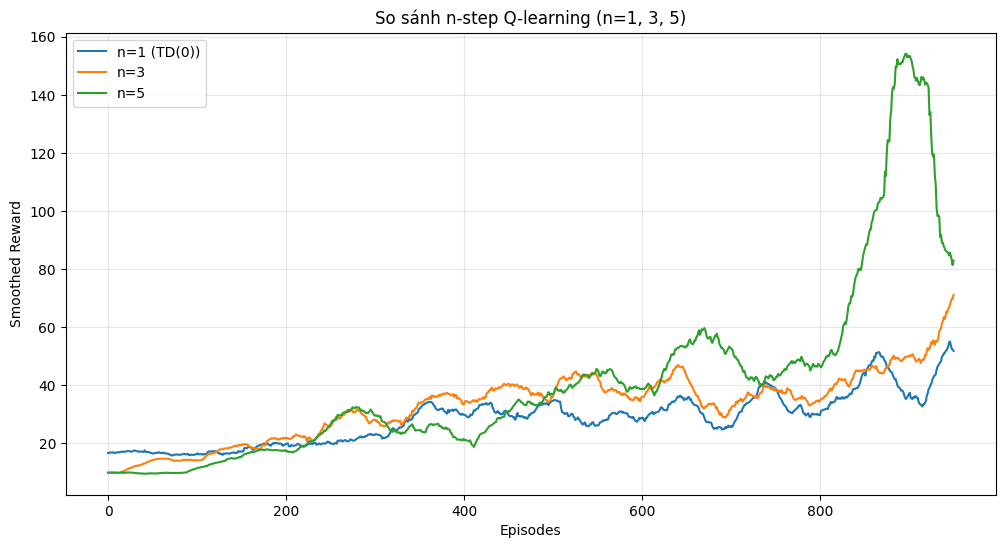

In [20]:
# Chạy thử nghiệm với các giá trị n khác nhau
results = {}
for n in [1, 3, 5]:
    print(f"Đang huấn luyện n={n}...")
    results[n] = train_n_step(n)

# Vẽ đồ thị so sánh (Learning Curve)
plt.figure(figsize=(12, 6))
for n, hist in results.items():
    # Làm mượt đường cong để dễ quan sát xu hướng
    smoothed = np.convolve(hist, np.ones(50)/50, mode='valid')
    label = f"n={n} (TD(0))" if n==1 else f"n={n}"
    plt.plot(smoothed, label=label)

plt.title("So sánh n-step Q-learning (n=1, 3, 5)")
plt.xlabel("Episodes")
plt.ylabel("Smoothed Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Đang huấn luyện n-step Q-learning với n=1...
Đang huấn luyện n-step Q-learning với n=3...
Đang huấn luyện n-step Q-learning với n=5...


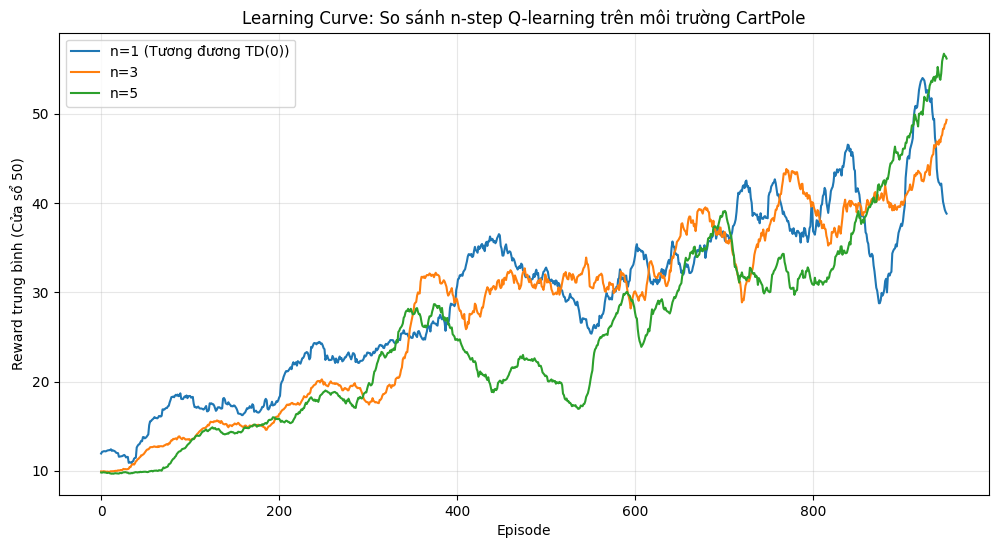

In [21]:

n_values = [1, 3, 5]
all_results = {}
episodes = 1000

for n in n_values:
    print(f"Đang huấn luyện n-step Q-learning với n={n}...")
    # Gọi hàm đã sửa lỗi của bạn
    rewards = train_n_step(n, episodes=episodes)
    all_results[n] = rewards

# Vẽ đồ thị
plt.figure(figsize=(12, 6))

for n in n_values:
    # Tính đường trung bình trượt (Moving Average) để đồ thị bớt nhiễu
    # Giúp quan sát xu hướng hội tụ rõ hơn (Câu 13)
    window_size = 50
    smoothed_rewards = np.convolve(all_results[n], np.ones(window_size)/window_size, mode='valid')
    
    label = f"n={n} (Tương đương TD(0))" if n == 1 else f"n={n}"
    plt.plot(smoothed_rewards, label=label)

plt.title("Learning Curve: So sánh n-step Q-learning trên môi trường CartPole")
plt.xlabel("Episode")
plt.ylabel(f"Reward trung bình (Cửa sổ {window_size})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Q-function Approximation

Xây dựng mạng Neural bằng PyTorch
- Mạng neural sẽ đóng vai trò xấp xỉ hàm Q, nhận đầu vào là trạng thái $s$ và trả về giá trị Q cho mọi hành động khả thi.

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        # Kiến trúc: Fully-connected + ReLU [cite: 140]
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim) # Output node = số action [cite: 141]

    def forward(self, x):
        x = F.relu(self.fc1(x)) # Hàm ReLU giúp học các đặc trưng phi tuyến [cite: 157]
        x = F.relu(self.fc2(x))
        return self.fc3(x)

Cài đặt Replay Buffer đơn giản
- Replay Buffer giúp lưu trữ trải nghiệm và lấy mẫu ngẫu nhiên để phá vỡ sự tương quan giữa các mẫu dữ liệu liên tiếp, giúp quá trình huấn luyện ổn định hơn.

In [23]:
import random
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

- Chúng ta sử dụng hàm loss dựa trên sai số bình phương giữa giá trị dự đoán và mục tiêu (TD Target).

In [25]:
def train_step(model, optimizer, buffer, batch_size, gamma):
    if len(buffer) < batch_size:
        return 0
    
    # Lấy mẫu từ buffer
    batch = buffer.sample(batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    # Chuyển sang Tensor
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones).unsqueeze(1)

    # Tính Q(s, a) hiện tại
    current_q = model(states).gather(1, actions)

    # Tính target: r + gamma * max Q(s', a) [cite: 144, 160]
    with torch.no_grad():
        max_next_q = model(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (gamma * max_next_q * (1 - dones))

    # Tính Loss: (Target - Current)^2 [cite: 144, 159]
    loss = F.mse_loss(current_q, target_q)

    # Tối ưu hóa
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

In [26]:
# Khởi tạo các đối tượng
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
model = QNetwork(state_dim, action_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
buffer = ReplayBuffer(10000)

# Tham số
episodes = 500 # Bạn có thể tăng lên để model học tốt hơn
batch_size = 64
gamma = 0.99
epsilon = 1.0 # Để exploration
epsilon_decay = 0.995
min_epsilon = 0.01

history_reward = []
history_loss = []

for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    ep_losses = []
    
    while not done:
        # Chọn hành động Epsilon-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            state_t = torch.FloatTensor(state).unsqueeze(0)
            action = model(state_t).argmax().item()
            
        next_state, reward, term, trunc, _ = env.step(action)
        done = term or trunc
        
        # Lưu vào Replay Buffer [cite: 147]
        buffer.push(state, action, reward, next_state, done)
        
        # Huấn luyện 1 bước [cite: 148]
        loss = train_step(model, optimizer, buffer, batch_size, gamma)
        if loss > 0:
            ep_losses.append(loss)
            
        state = next_state
        total_reward += reward
        
    # Cập nhật epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    # Lưu lịch sử
    history_reward.append(total_reward)
    avg_loss = np.mean(ep_losses) if ep_losses else 0
    history_loss.append(avg_loss)
    
    # In kết quả mỗi 50 episode
    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1}/{episodes} | Reward: {total_reward:.1f} | Avg Loss: {avg_loss:.5f} | Epsilon: {epsilon:.3f}")

print("Huấn luyện hoàn tất!")

C:\Users\Admin\AppData\Local\Temp\ipykernel_16476\462241261.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  states = torch.FloatTensor(states)


Episode 50/500 | Reward: 27.0 | Avg Loss: 462.05659 | Epsilon: 0.778
Episode 100/500 | Reward: 26.0 | Avg Loss: 4107.75979 | Epsilon: 0.606
Episode 150/500 | Reward: 134.0 | Avg Loss: 5950.72979 | Epsilon: 0.471
Episode 200/500 | Reward: 79.0 | Avg Loss: 585.44731 | Epsilon: 0.367
Episode 250/500 | Reward: 192.0 | Avg Loss: 164.61330 | Epsilon: 0.286
Episode 300/500 | Reward: 109.0 | Avg Loss: 32.72093 | Epsilon: 0.222
Episode 350/500 | Reward: 124.0 | Avg Loss: 47.81767 | Epsilon: 0.173
Episode 400/500 | Reward: 106.0 | Avg Loss: 153.61010 | Epsilon: 0.135
Episode 450/500 | Reward: 178.0 | Avg Loss: 207.50374 | Epsilon: 0.105
Episode 500/500 | Reward: 500.0 | Avg Loss: 43.50275 | Epsilon: 0.082
Huấn luyện hoàn tất!


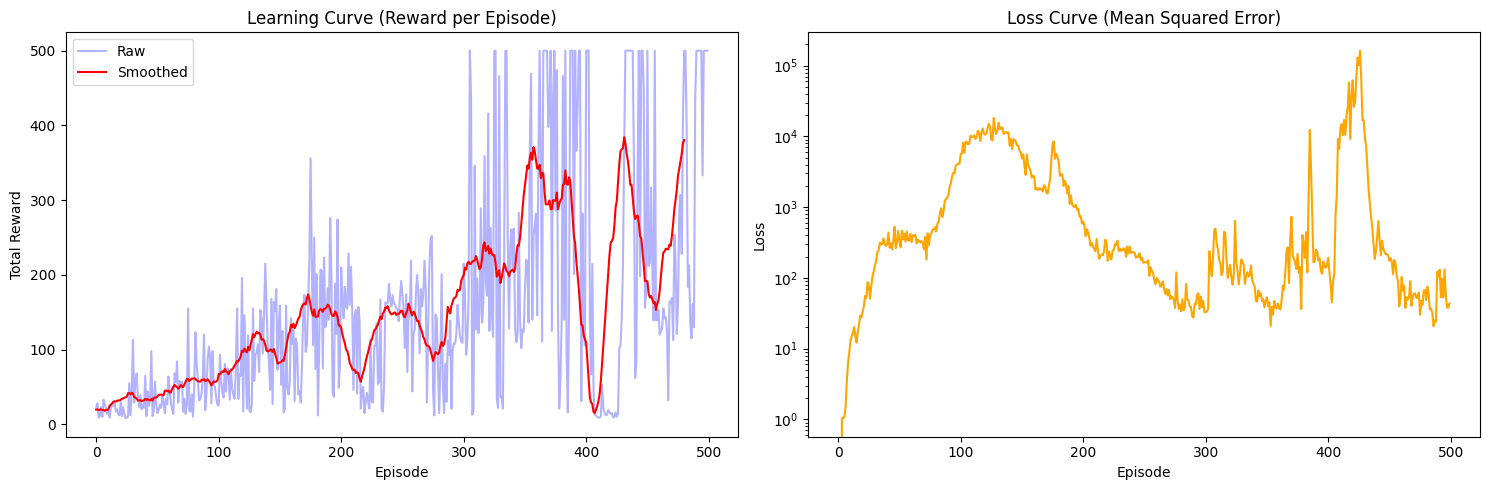

In [27]:
plt.figure(figsize=(15, 5))

# Biểu đồ Reward (Learning Curve) [cite: 150, 164]
plt.subplot(1, 2, 1)
plt.plot(history_reward, alpha=0.3, color='blue', label='Raw')
plt.plot(np.convolve(history_reward, np.ones(20)/20, mode='valid'), color='red', label='Smoothed')
plt.title("Learning Curve (Reward per Episode)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()

# Biểu đồ Loss [cite: 150, 163]
plt.subplot(1, 2, 2)
plt.plot(history_loss, color='orange')
plt.title("Loss Curve (Mean Squared Error)")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.yscale('log') # Thường dùng log scale để dễ quan sát sự hội tụ của loss

plt.tight_layout()
plt.show()